### Wczytanie danych (i bibliotek)

# 1. Eksploracyjna analiza danych

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, mean_squared_error, 
                              r2_score, classification_report)
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

import warnings
warnings.filterwarnings("ignore")

### Wczytanie i zrozumienie danych

In [2]:
df = pd.read_csv('Hotel Reservations.csv')
print(f"Liczba wierszy: {df.shape[0]}, liczba kolumn: {df.shape[1]}")
df.head()

Liczba wierszy: 36275, liczba kolumn: 19


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


### Typy danych i zmiennych

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [4]:
print("Zmienne numeryczne")
df.describe()

Zmienne numeryczne


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [5]:
print("Zmienne opisowe")
df.describe(include='object')

Zmienne opisowe


,Booking_ID,type_of_meal_plan,room_type_reserved,market_segment_type,booking_status
count,36275,36275,36275,36275,36275
unique,36275,4,7,5,2
top,INN00001,Meal Plan 1,Room_Type 1,Online,Not_Canceled
freq,1,27835,28130,23214,24390


In [6]:
df.market_segment_type.unique()

array(['Offline', 'Online', 'Corporate', 'Aviation', 'Complementary'],
      dtype=object)

### Sprawdzenie brakujących danych

In [7]:
print("Liczba brakujących wartości")
df.isnull().sum()

Liczba brakujących wartości


Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [8]:
print("Liczba duplikatów")
df.duplicated().sum()

Liczba duplikatów


0

In [9]:
df['booking_status'].value_counts(normalize=True) # Można tym sprawdzić sobie stosunek cancelled/not cancelled

booking_status
Not_Canceled    0.672364
Canceled        0.327636
Name: proportion, dtype: float64

### Hipotezy

Analizująć kolejne kolumny z ramki danych możemy postawić następujące hipotezy:
- im wcześniej robiono rezerwację, tym większa szansa anulacji (lead_time)
- powracający goście mogą rzadziej anulować rezerwacje (repeated_guest)
- segmenty kanałów sprzedaży mogą różnie wpływać na szansę anulacji, np.rezerwacje firmowe mogą być rzadziej odwoływane (market_segment_type)


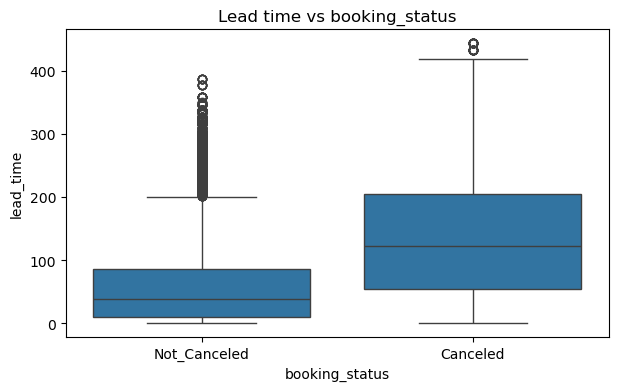

In [10]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='booking_status', y='lead_time')
plt.title('Lead time vs booking_status')
plt.show()

Im wcześniej robiono rezerwację, tym większa szansa na odwołanie.

In [11]:
pd.crosstab(df["repeated_guest"], df["booking_status"], normalize="index") * 100

booking_status,Canceled,Not_Canceled
repeated_guest,,
0,33.580422,66.419578
1,1.720430,98.279570


Powracający goście mają o wiele rzadziej odwołują rezerwacje.

booking_status,Canceled,Not_Canceled
market_segment_type,,
Aviation,29.60,70.40
Complementary,0.00,100.00
Corporate,10.91,89.09
Offline,29.95,70.05
Online,36.51,63.49


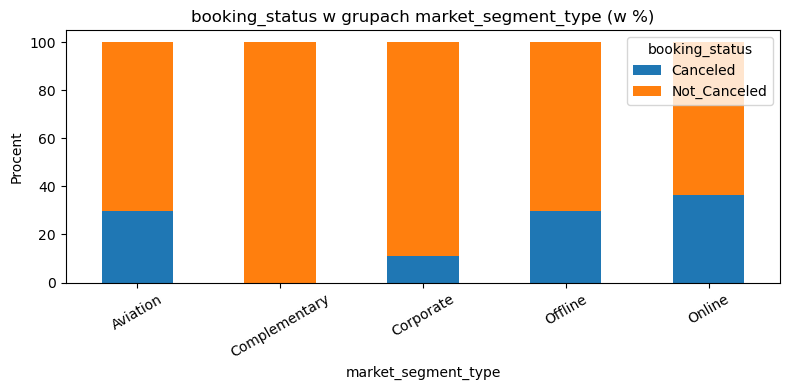

In [12]:
mseg = pd.crosstab(df["market_segment_type"], df["booking_status"], normalize="index") * 100
mseg = mseg.round(2)
display(mseg)
mseg.plot(kind="bar", stacked=True, figsize=(8,4))
plt.title("booking_status w grupach market_segment_type (w %)")
plt.xlabel("market_segment_type")
plt.ylabel("Procent")
plt.legend(title="booking_status")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Rezerwacje robione online są najbardziej podatne na anulowanie. Najmniej odwołanych rezerwacji było w segmencie "Compemantary".

### Analiza rozkładów i zależności

In [13]:
target_col = 'booking_status'
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols.remove(target_col)
print('Numeryczne:', num_cols)
print("Kategoryczne:", cat_cols)

Numeryczne: ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']
Kategoryczne: ['Booking_ID', 'type_of_meal_plan', 'room_type_reserved', 'market_segment_type']


In [14]:
df.no_of_previous_bookings_not_canceled

0        0
1        0
2        0
3        0
4        0
        ..
36270    0
36271    0
36272    0
36273    0
36274    0
Name: no_of_previous_bookings_not_canceled, Length: 36275, dtype: int64

### Najważniejsze zmienne numeryczne

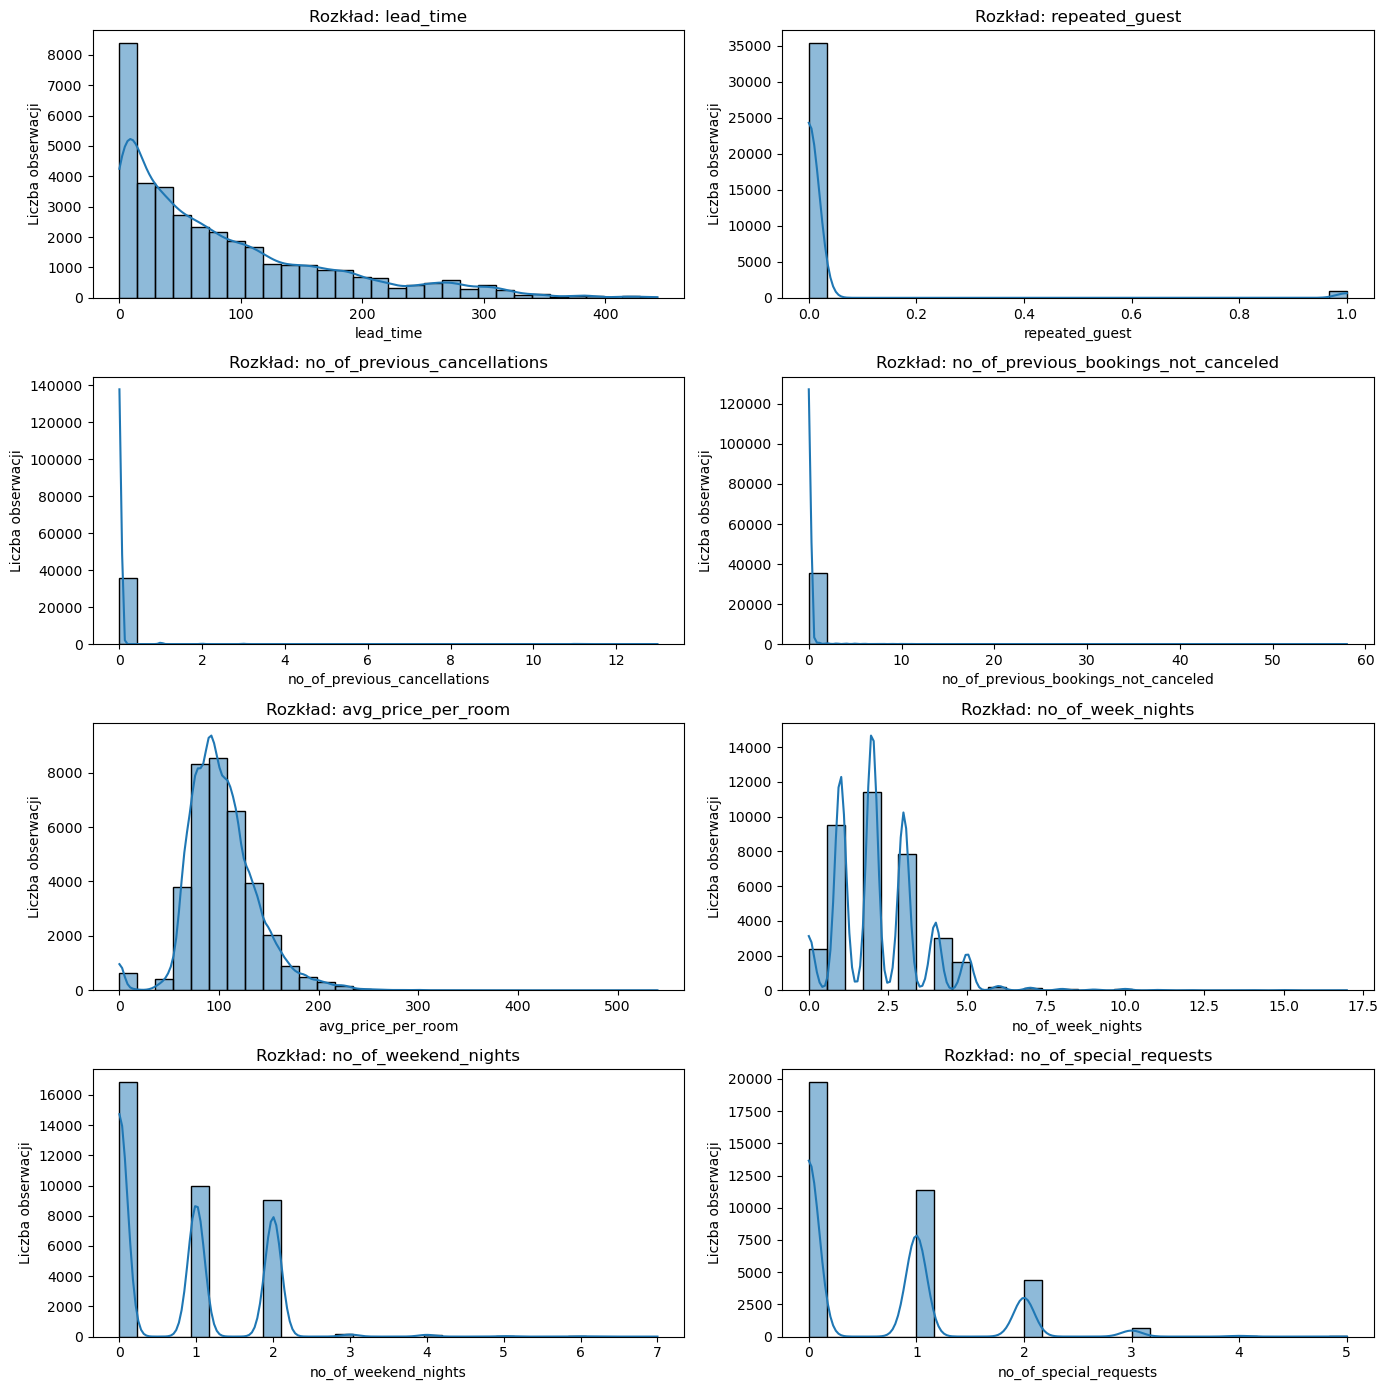

In [16]:
important_num = [
    'lead_time',
    'repeated_guest',
    'no_of_previous_cancellations',
    'no_of_previous_bookings_not_canceled',
    'avg_price_per_room',
    'no_of_week_nights',
    'no_of_weekend_nights',
    'no_of_special_requests'
]

fig, ax = plt.subplots(4, 2, figsize=(14, 14))

for i, col in enumerate(important_num):
    sns.histplot(df[col], bins=30, kde=True, ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(f'Rozkład: {col}')
    ax[i//2, i%2].set_xlabel(col)
    ax[i//2, i%2].set_ylabel('Liczba obserwacji')

plt.tight_layout()
plt.show()

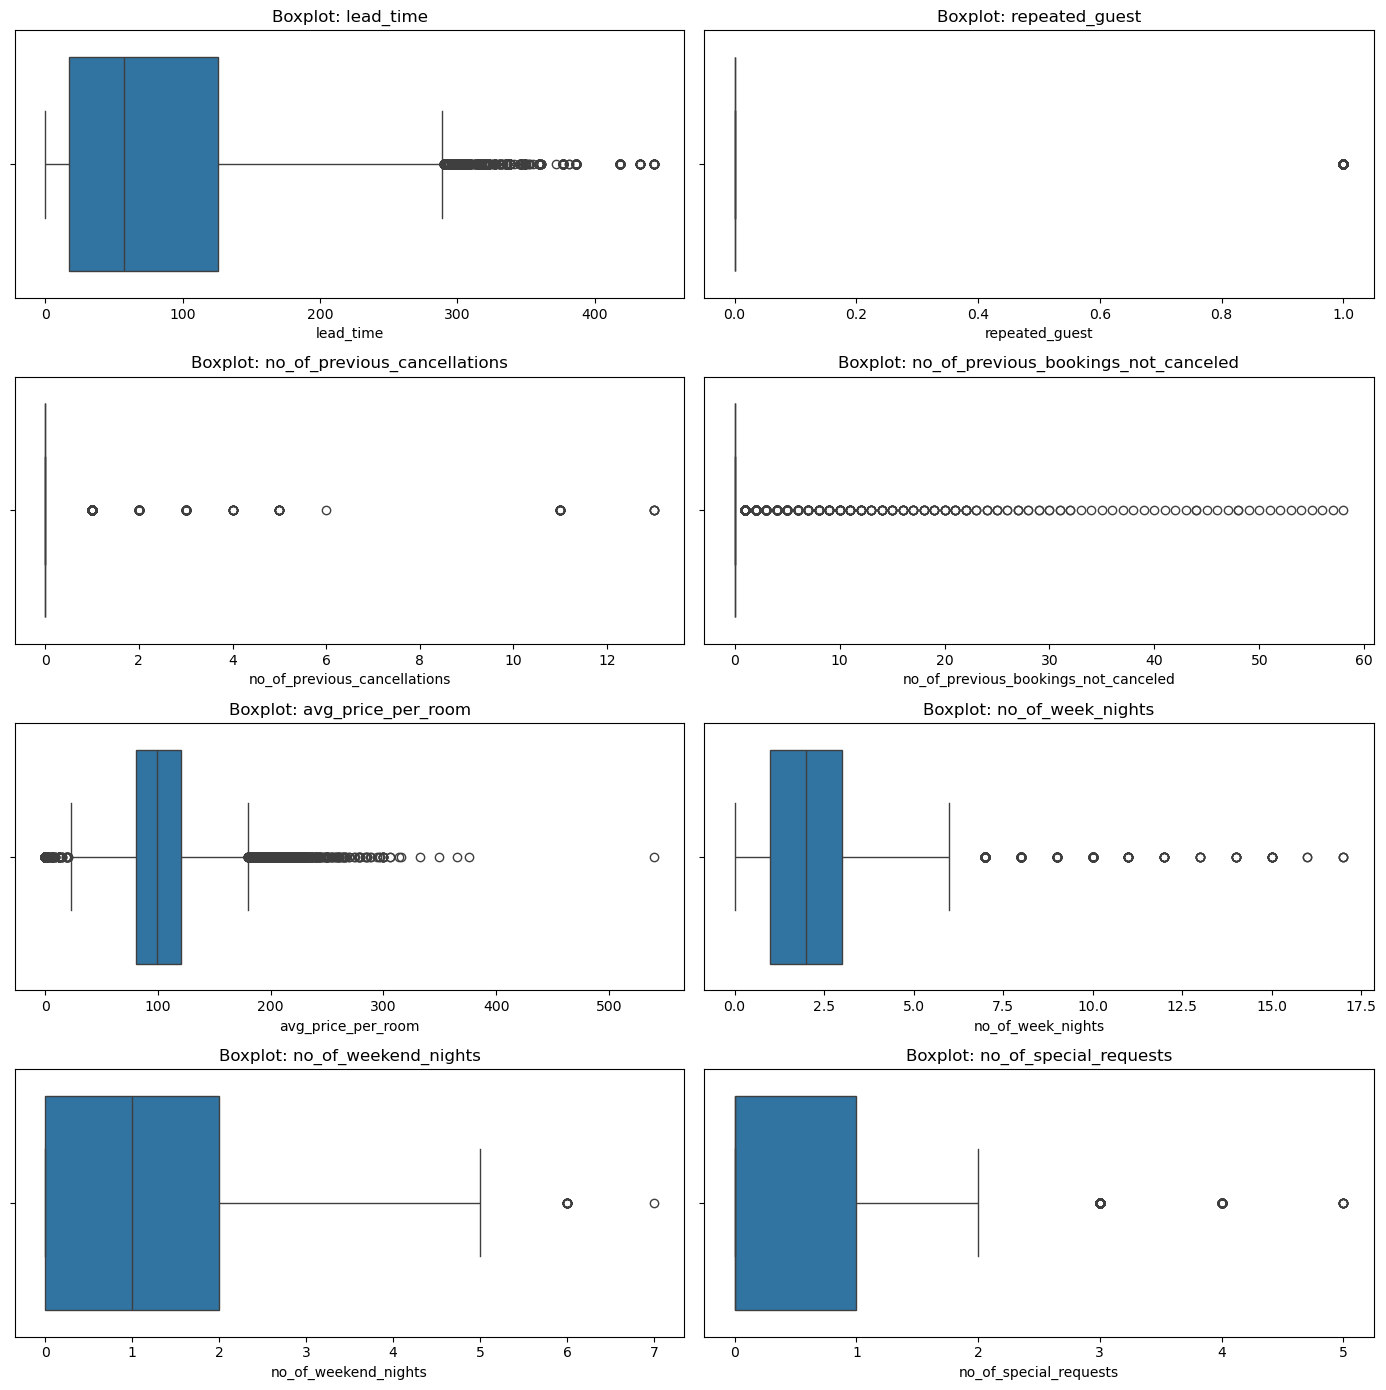

In [17]:
fig, ax = plt.subplots(4, 2, figsize=(14, 14))

for i, col in enumerate(important_num):
    sns.boxplot(x=df[col], ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(f'Boxplot: {col}')
    ax[i//2, i%2].set_xlabel(col)

plt.tight_layout()
plt.show()

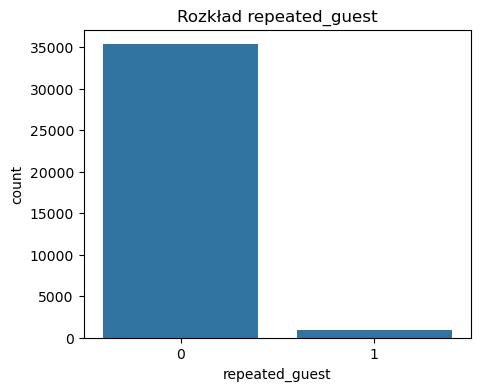

In [18]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='repeated_guest')
plt.title("Rozkład repeated_guest")
plt.show() 
# jest to zmienna binarna, więc lepiej ją widać na wykresie słupkowym

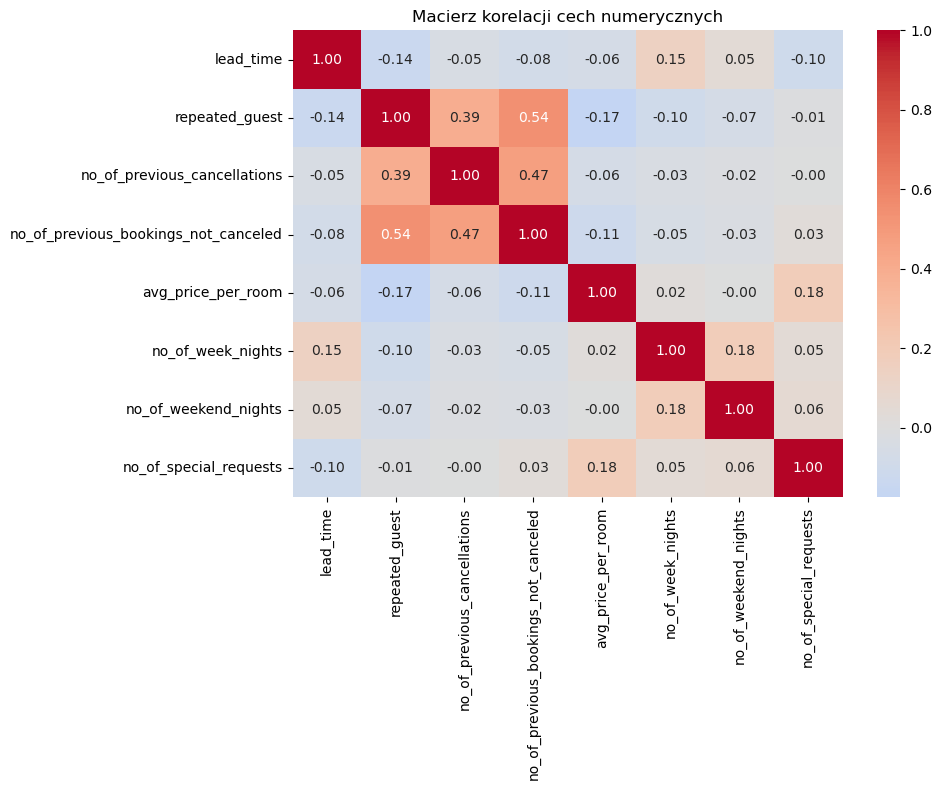

In [19]:
corr = df[important_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Macierz korelacji cech numerycznych')
plt.tight_layout()
plt.show()

Widać, że najbardziej skorelowane ze sobą cechy to:
- repeated_guest i no_of_previous_bookings_not_canceled
- repeated_guest i no_of_previous_cancellations
- no_of_previous_cancellations i no_of_previous_bookings_not_canceled
Jest to zgodne z intuicją - poracający goście częściej posiadają historię wcześniejszych rezerwacji. Pozostałe korelacje nie wskazują na istotane zależności liniowe.


### Najważniejsze zmienne kategoryczne

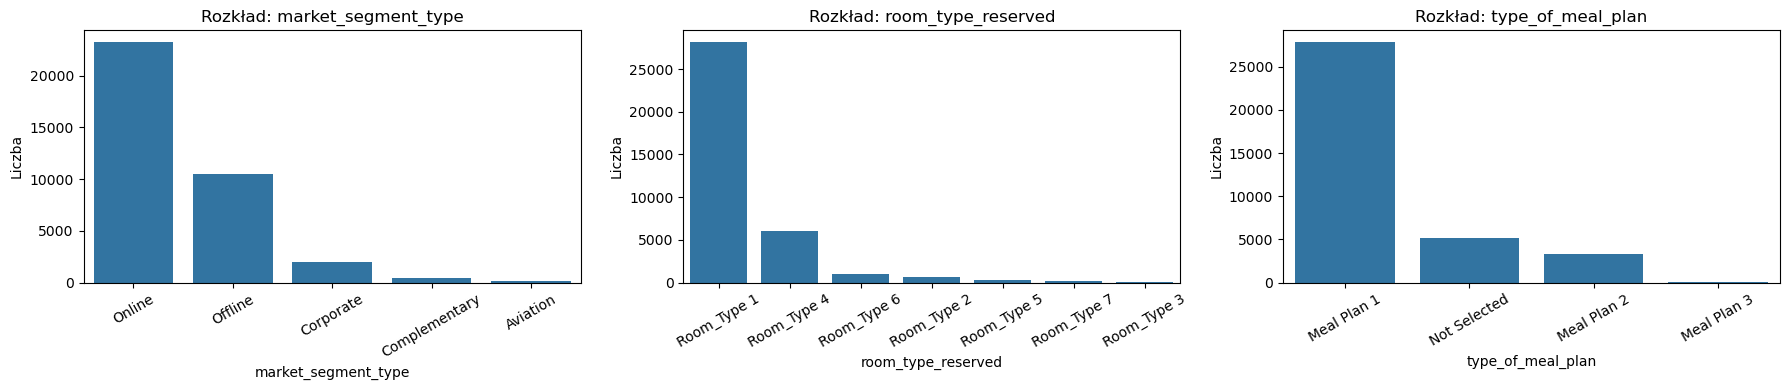

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

important_cat = [
    "market_segment_type",
    "room_type_reserved",
    "type_of_meal_plan"
]

for i, col in enumerate(important_cat):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax[i])
    ax[i].set_title(f"Rozkład: {col}")
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Liczba")
    ax[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Wnioski

Na podstawie powyższych wykresów, możemy zauważyć, że:
- większość klientów rezerwuje do ok. 3 miesięcy z wyprzedzeniem, ale część rezerwuje bardzo wcześnie, nawet ponad rok wcześniej (dużo wartości odstających)
- więcej wartości odstających przy braku anulowania rezerwacji, niż przy anulowaniu rezerwacji, czyli większość klientów nie ma historii anulacji
- cena pokojów ma bardzo dużo outlierów
- większość pobytów jest krótkich, zwłaszcza weekendowych
- większość gości nie zgłasza specjalnych próśb
- najwięcej rezerwacji było robionych online
- najczęściej był reerwowany pokój nr 1
- najczęściej był wybierany posiłek nr 1

Badanie niuansu w postaci outlierów ceny pokoju wynoszącej 0

In [21]:
free_rooms = df[df['avg_price_per_room'] == 0]

print(f"Liczba rezerwacji z ceną 0: {len(free_rooms)} (co stanowi {len(free_rooms)/len(df)*100:.2f}% całego zbioru)\n")

print("Z jakiego segmentu rynku pochodzą darmowe pokoje?")
print(free_rooms['market_segment_type'].value_counts())

print("\nCzy są to goście powracający (1 = Tak, 0 = Nie)?")
print(free_rooms['repeated_guest'].value_counts())

print("\nJaki jest ich status anulowania?")
print(free_rooms['booking_status'].value_counts())

Liczba rezerwacji z ceną 0: 545 (co stanowi 1.50% całego zbioru)

Z jakiego segmentu rynku pochodzą darmowe pokoje?
market_segment_type
Complementary    354
Online           191
Name: count, dtype: int64

Czy są to goście powracający (1 = Tak, 0 = Nie)?
repeated_guest
0    418
1    127
Name: count, dtype: int64

Jaki jest ich status anulowania?
booking_status
Not_Canceled    539
Canceled          6
Name: count, dtype: int64


# 2. Przetwarzanie danych

### Usunięcie kolumny Booking_ID

In [22]:
df = df.drop('Booking_ID', axis = 1)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


Zmienna ta nie wnosiłą nic wartościowego pod względem implementacji modelu.

### Kodowanie zmiennej docelowej

In [23]:
target = {'Canceled': 1, 'Not_Canceled': 0} # Zmiana booking_status na liczbe
df['booking_status'] = df['booking_status'].replace(target)
print("Canceled = 1, Not_Canceled = 0")
df.describe()

Canceled = 1, Not_Canceled = 0


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655,0.327636
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236,0.469358
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000,1.000000


### Dodanie nowych kolumn

In [24]:
df['is_free_room'] = (df['avg_price_per_room'] == 0).astype(int)

W EDA wyszło, że dla ceny pokoju wynoszącej 0, bardzo rzadko rezerwacja jest anulowana. Z tego względu tworzona jest kolumna `is_free_room`, która binarnie mówi o tym, czy pokój był darmowy.

In [25]:
total_nights = df['no_of_week_nights'] + df['no_of_weekend_nights']

df['is_zero_nights'] = (total_nights == 0).astype(int)

zero_nights_count = df['is_zero_nights'].sum()
print(f"Liczba rezerwacji z liczbą nocy równą 0: {zero_nights_count}")

zero_nights_rates = df.groupby('is_zero_nights')['booking_status'].mean() * 100

print("\nWskaźnik anulacji (%):")
print(f"Standardowy pobyt (więcej niż 0 nocy): {zero_nights_rates[0]:.2f}%")
if zero_nights_count > 0:
    print(f"Pobyt 0-dniowy (is_zero_nights = 1):   {zero_nights_rates[1]:.2f}%")

Liczba rezerwacji z liczbą nocy równą 0: 78

Wskaźnik anulacji (%):
Standardowy pobyt (więcej niż 0 nocy): 32.83%
Pobyt 0-dniowy (is_zero_nights = 1):   2.56%


In [26]:

print("Ilu gości spełnia oba warunki na raz?")
crosstab_result = pd.crosstab(
    df['is_zero_nights'], 
    df['is_free_room'], 
    margins=True,
    rownames=['Day Use (0 nocy)'], 
    colnames=['Darmowy (0 zł)']
)
display(crosstab_result)

korelacja = df[['is_zero_nights', 'is_free_room']].corr().iloc[0, 1]
print(f"\nWspółczynnik korelacji wynosi: {korelacja:.4f}")

Ilu gości spełnia oba warunki na raz?


Darmowy (0 zł),0,1,All
Day Use (0 nocy),,,
0,35730,467,36197
1,0,78,78
All,35730,545,36275



Współczynnik korelacji wynosi: 0.3759


### Podział danych na zbiór treningowy, walidacyjny i testowy w proporcjach 80/10/10

In [27]:
X = df.drop('booking_status', axis = 1)
y = df['booking_status']

test_size = 0.10
val_size = 0.10
X_train_val, X_test, y_train_val, y_test = train_test_split( # 10%
    X, y, test_size=test_size, stratify=y, random_state=123)

In [28]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_size/(1 - test_size), stratify=y_train_val, random_state=123)

### Kodowanie zmiennych kategorycznych

In [29]:
num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeryczne cechy:", num_features)
print("Kategoryczne cechy:", cat_features)

Numeryczne cechy: ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']
Kategoryczne cechy: ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']


In [30]:
num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [31]:
data_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor)
])

data_pipeline.fit(X_train)

feature_names = (
    pd.Index(data_pipeline.named_steps['preprocessor'].get_feature_names_out())
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

X_train_processed = pd.DataFrame(data_pipeline.transform(X_train),
                                columns=feature_names)

X_val_processed = pd.DataFrame(data_pipeline.transform(X_val),
                                columns=feature_names)

X_test_processed = pd.DataFrame(data_pipeline.transform(X_test),
                                columns=feature_names)

# 3. Trening i ewaluacja modeli

In [32]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    y_prob = model.predict_proba(X_v)[:, 1]
    return {
        'Model': name,
        'Accuracy':  np.round(accuracy_score(y_v, y_pred), 4),
        'Precision': np.round(precision_score(y_v, y_pred), 4),
        'Recall':    np.round(recall_score(y_v, y_pred), 4),
        'F1-Score':  np.round(f1_score(y_v, y_pred), 4),
        'ROC-AUC':   np.round(roc_auc_score(y_v, y_prob), 4),
    }

results = []
trained_models = {}

### Regresja logistyczna

In [33]:
lr = LogisticRegression(max_iter=1000, random_state=123)
res = evaluate_model(lr, X_train_processed, y_train, X_val_processed, y_val, 'Logistic Regression')
results.append(res)
trained_models['Logistic Regression'] = lr

for k, v in res.items():
    print(f"{k}: {v}")

Model: Logistic Regression
Accuracy: 0.8126
Precision: 0.7498
Recall: 0.6426
F1-Score: 0.692
ROC-AUC: 0.8668


### Drzewo decyzyjne

In [34]:
dt = DecisionTreeClassifier(random_state=123)
res = evaluate_model(
    dt,
    X_train_processed, y_train,
    X_val_processed, y_val,
    'Decision Tree'
)

results.append(res)
trained_models['Decision Tree'] = dt

for k, v in res.items():
    print(f"{k}: {v}")

Model: Decision Tree
Accuracy: 0.8768
Precision: 0.8112
Recall: 0.8133
F1-Score: 0.8123
ROC-AUC: 0.8632


### Random forest

In [35]:
rf = RandomForestClassifier(random_state=123)

res = evaluate_model(
    rf,
    X_train_processed, y_train,
    X_val_processed, y_val,
    'Random Forest'
)

results.append(res)
trained_models['Random Forest'] = rf

for k, v in res.items():
    print(f"{k}: {v}")

Model: Random Forest
Accuracy: 0.9123
Precision: 0.8984
Recall: 0.8259
F1-Score: 0.8606
ROC-AUC: 0.9602


### SVC

In [ ]:
# sv = SVC(random_state=123, probability=True)

# res = evaluate_model(
#     sv,
#     X_train_processed, y_train,
#     X_val_processed, y_val,
#     'SVC'
# )

# results.append(res)
# trained_models['SVC'] = sv

# for k, v in res.items():
#     print(f"{k}: {v}")

In [ ]:
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300, 400],
    'max_depth': [10, 15, 20, 25, 30, 35, 40, None],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 3]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=123),
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=123
)

print('Szukanie najlepszych parametrów...')
random_search.fit(X_train_processed, y_train)

print('Najlepsze znalezione parametry:', random_search.best_params_)

best_rf = random_search.best_estimator_
res_tuned = evaluate_model(best_rf, X_train_processed, y_train, X_val_processed, y_val, 'Tuned Random Forest')

results.append(res_tuned)
trained_models['Tuned Random Forest'] = best_rf

print('\nWyniki modelu po tuningu na zbiorze walidacyjnym:')
for k, v in res_tuned.items():
    print(f'{k}: {v}')

Szukanie najlepszych parametrów...
Najlepsze znalezione parametry: {'n_estimators': 100, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_depth': None}

Wyniki modelu po tuningu na zbiorze walidacyjnym:
Model: Tuned Random Forest
Accuracy: 0.9104
Precision: 0.8899
Recall: 0.8293
F1-Score: 0.8585
ROC-AUC: 0.9612


## Porównanie modeli

In [ ]:
results_df = pd.DataFrame(results).set_index('Model')
print("Porównanie modeli na zbiorze walidacyjnym")
print(results_df)

print("\nNajlepszy model wg. metryki")
for col in results_df.columns:
    best = results_df[col].idxmax()
    print(f"  {col:12s}: {best} ({results_df.loc[best, col]:.4f})")


Porównanie modeli na zbiorze walidacyjnym
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8126     0.7498  0.6426    0.6920   0.8668
Decision Tree          0.8768     0.8112  0.8133    0.8123   0.8632
Random Forest          0.9123     0.8984  0.8259    0.8606   0.9602
Tuned Random Forest    0.9104     0.8899  0.8293    0.8585   0.9612

Najlepszy model wg. metryki
  Accuracy    : Random Forest (0.9123)
  Precision   : Random Forest (0.8984)
  Recall      : Tuned Random Forest (0.8293)
  F1-Score    : Random Forest (0.8606)
  ROC-AUC     : Tuned Random Forest (0.9612)


## Wybór najlepszego modelu i ewaluacja na zbiorze testowym (todo)

In [ ]:
final_model = trained_models['Tuned Random Forest']

y_test_pred = final_model.predict(X_test_processed)
y_test_prob = final_model.predict_proba(X_test_processed)[:, 1]

print("Wyniki na zbiorze testowym")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_prob):.4f}")

print(classification_report(y_test, y_test_pred))

Wyniki na zbiorze testowym
Accuracy:  0.9005
Precision: 0.8703
Recall:    0.8183
F1-Score:  0.8435
ROC-AUC:   0.9589
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      2439
           1       0.87      0.82      0.84      1189

    accuracy                           0.90      3628
   macro avg       0.89      0.88      0.89      3628
weighted avg       0.90      0.90      0.90      3628



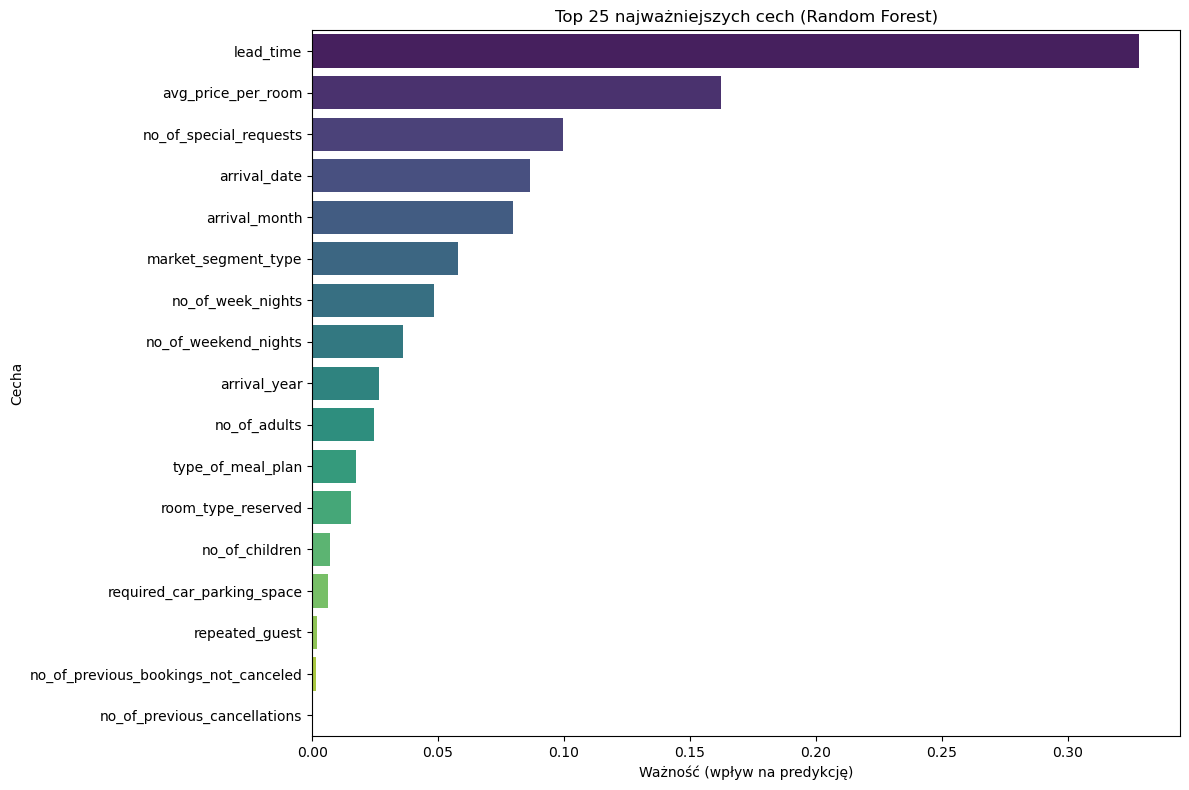

In [ ]:
# Pobranie najlepszego wytrenowanego modelu
best_rf = trained_models['Tuned Random Forest']

# Pobranie wartości Feature Importance
importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Cecha': X_train_processed.columns,
    'Ważność': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Ważność', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df.head(25), x='Ważność', y='Cecha', palette='viridis')
plt.title('Top 25 najważniejszych cech (Random Forest)')
plt.xlabel('Ważność (wpływ na predykcję)')
plt.ylabel('Cecha')
plt.tight_layout()
plt.show()

# 4. Interpretacja modelu i wnioski biznesowe

Na podstawie wykresu ważności cech widać, że największy wpływ na predykcję mają:
- lead_time
- avg_price_per_room
- no_of_special_requests
- arrival_date, arrival_month
- market_segment_type
- no_of_wkke_nights, no_of_weekend_nights.

Częściowo pokrywa się to z stawianymi hipotezami. Ustaliliśmy już, że im wcześniej robiono rezerwację, tym większa szansa na anulowanie. Jest to najważniejszy czynnik, dlatego dobrze jest się mu przyjrzeć.

### Lead_time

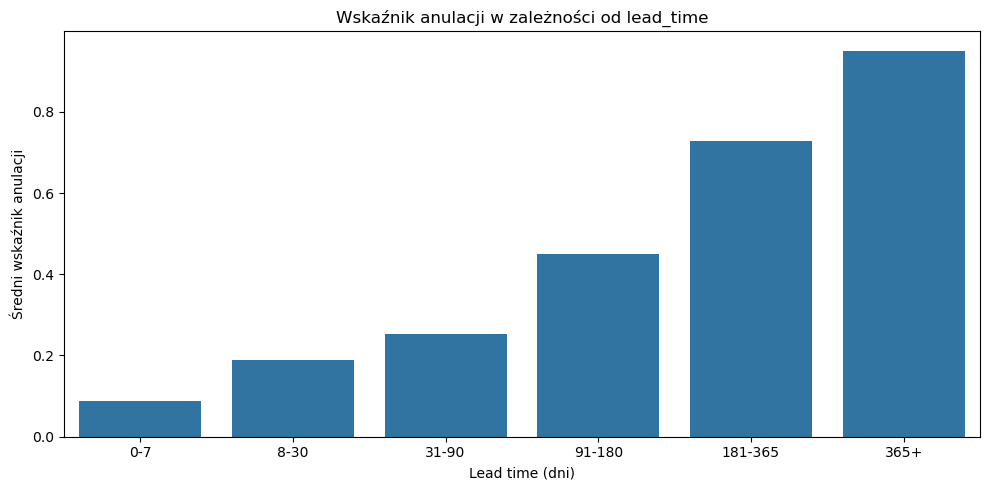

In [36]:
target_col = 'booking_status'

df_plot = df.copy()

df_plot['lead_time_bin'] = pd.cut(
    df_plot['lead_time'],
    bins=[-1, 7, 30, 90, 180, 365, df_plot['lead_time'].max()],
    labels=['0-7', '8-30', '31-90', '91-180', '181-365', '365+']
)

lead_cancel_rate = df_plot.groupby('lead_time_bin')[target_col].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=lead_cancel_rate, x='lead_time_bin', y=target_col)
plt.title('Wskaźnik anulacji w zależności od lead_time')
plt.xlabel('Lead time (dni)')
plt.ylabel('Średni wskaźnik anulacji')
plt.tight_layout()
plt.show()

In [37]:
df_plot['lead_time_bin']

0        181-365
1            0-7
2            0-7
3        181-365
4          31-90
          ...   
36270      31-90
36271    181-365
36272     91-180
36273      31-90
36274    181-365
Name: lead_time_bin, Length: 36275, dtype: category
Categories (6, object): ['0-7' < '8-30' < '31-90' < '91-180' < '181-365' < '365+']

### Avg_price_per_room

To druga najważniejszza cecha. Zazwyczaj wyższa cena zwiększa ryzyko anulacji - klienci mogą szukać tańszych zamienników.

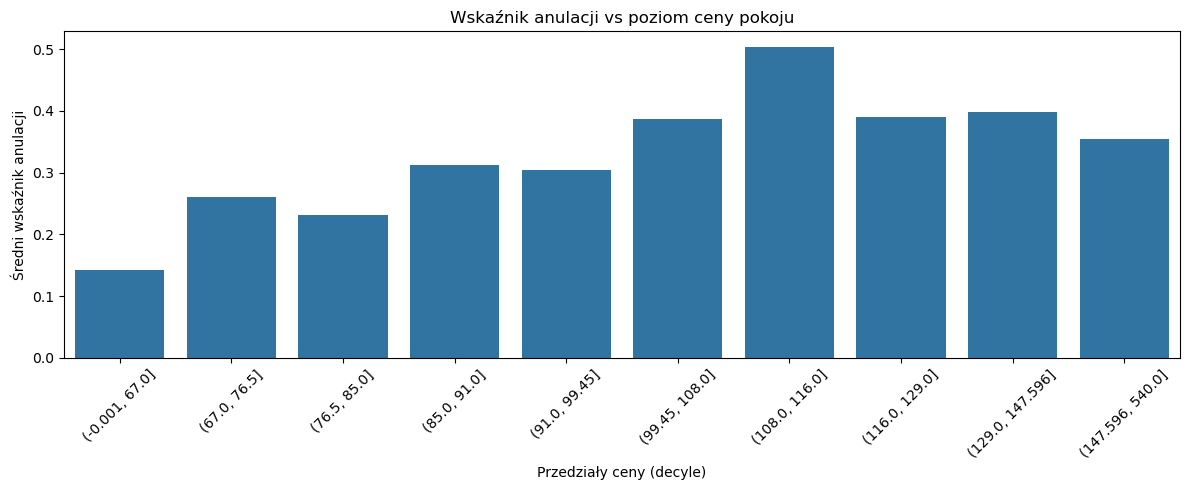

In [38]:
df_plot = df.copy()

df_plot['price_bin'] = pd.qcut(df_plot['avg_price_per_room'], q=10, duplicates='drop')

price_cancel_rate = df_plot.groupby('price_bin')[target_col].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=price_cancel_rate, x='price_bin', y=target_col)
plt.title('Wskaźnik anulacji vs poziom ceny pokoju')
plt.xlabel('Przedziały ceny (decyle)')
plt.ylabel('Średni wskaźnik anulacji')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### No_of_special_requests

Zazwyczaj klienci, którzy zgłaszają specjalne życzenia są bardziej zdecydowani i mniej skłonni do anulowania.

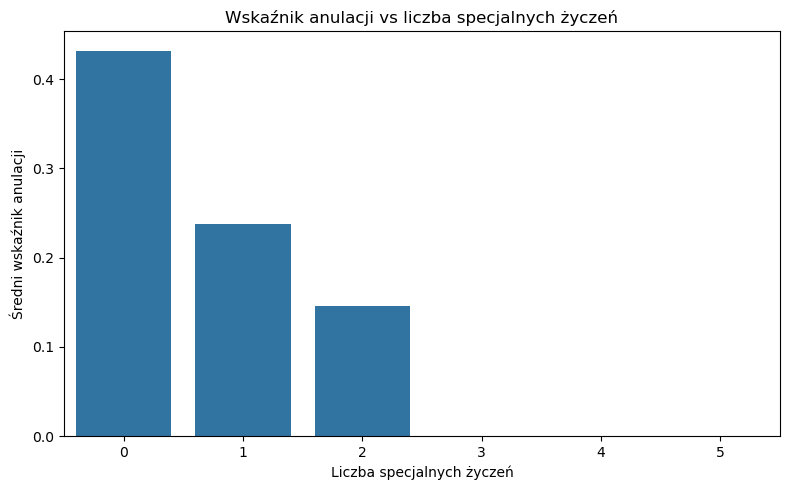

In [39]:
special_req_cancel = df.groupby('no_of_special_requests')[target_col].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=special_req_cancel, x='no_of_special_requests', y=target_col)
plt.title('Wskaźnik anulacji vs liczba specjalnych życzeń')
plt.xlabel('Liczba specjalnych życzeń')
plt.ylabel('Średni wskaźnik anulacji')
plt.tight_layout()
plt.show()

### Arrival_month, arrival_date
Moment przyjazdu wpływa na przewidywanie anulacji, najpewniej przez sezonowość pobytu, święta/ długie weekendy. Widać, że najwięcej anulowanych rezerwacji przypada na miesiące letnie, kiedy to plany klientów mogą być bardziej podatne na zmiany.

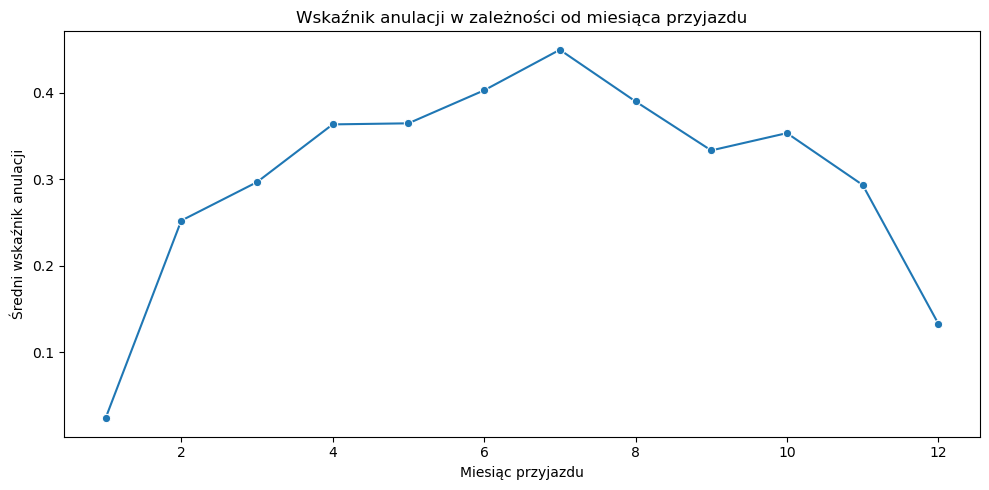

In [ ]:
month_cancel = df.groupby('arrival_month')[target_col].mean().reset_index()

month_cancel = month_cancel.sort_values('arrival_month')

plt.figure(figsize=(10, 5))
sns.lineplot(data=month_cancel, x='arrival_month', y=target_col, marker='o')
plt.title('Wskaźnik anulacji w zależności od miesiąca przyjazdu')
plt.xlabel('Miesiąc przyjazdu')
plt.ylabel('Średni wskaźnik anulacji')
plt.tight_layout()
plt.show()

### Market_segment_type
Różne segmenty zachowują sie inaczej względem anulacji.

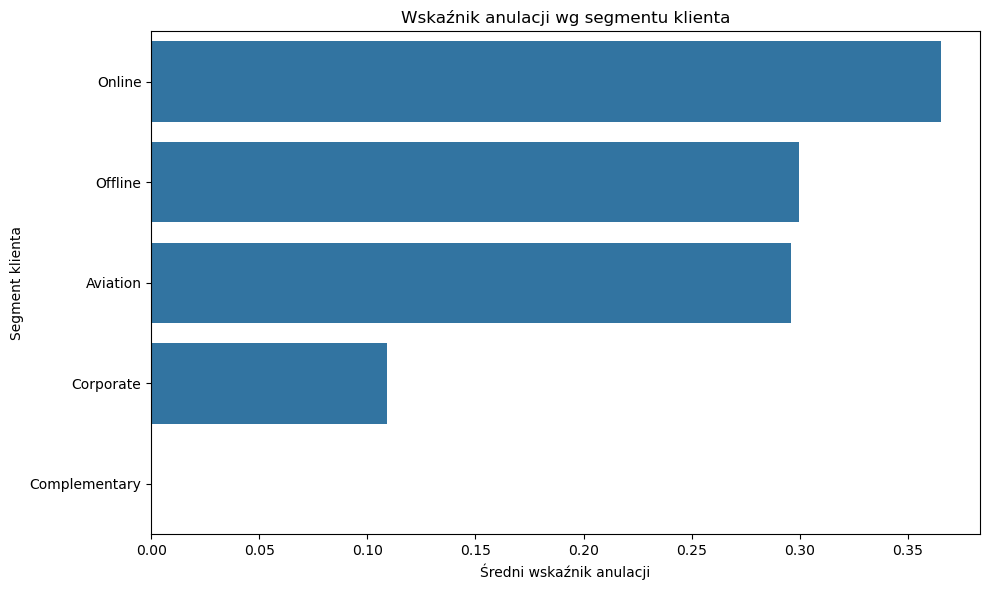

In [40]:
segment_cancel = (
    df.groupby('market_segment_type')[target_col]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=segment_cancel, x=target_col, y='market_segment_type')
plt.title('Wskaźnik anulacji wg segmentu klienta')
plt.xlabel('Średni wskaźnik anulacji')
plt.ylabel('Segment klienta')
plt.tight_layout()
plt.show()

### No_of_week_nights + no_of_weekend_nights

Wykres sugeruje wzrost anulacji dla dłuższych pobytów, jednak boxploty rozkłądu cech pokazują, że długie pobyty występują relatywnie rzadko. Najbardziej wiarygodna interpretacja dotyczy krótkich i średnich pobytów, które dominują w zbiorze danych.

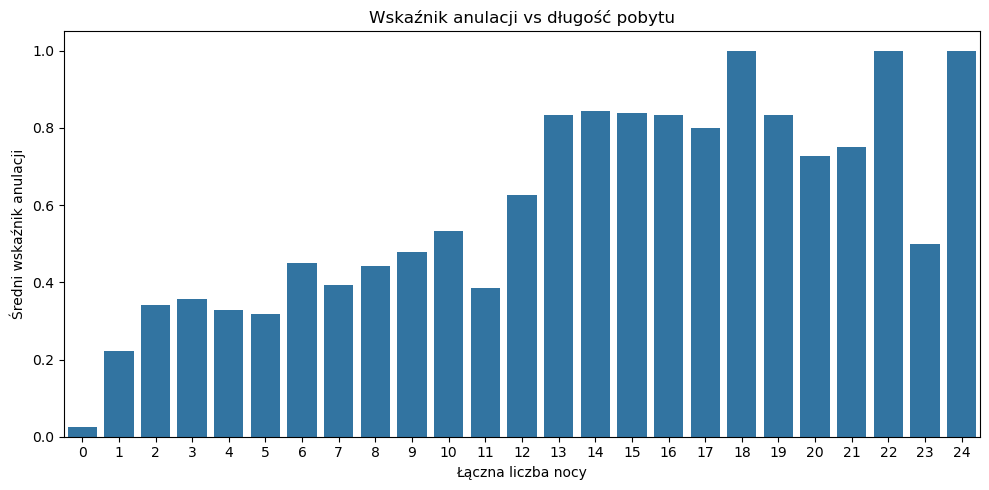

In [43]:
df_plot = df.copy()
df_plot['total_nights'] = df_plot['no_of_week_nights'] + df_plot['no_of_weekend_nights']

nights_cancel = df_plot.groupby('total_nights')[target_col].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=nights_cancel, x='total_nights', y=target_col)
plt.title('Wskaźnik anulacji vs długość pobytu')
plt.xlabel('Łączna liczba nocy')
plt.ylabel('Średni wskaźnik anulacji')
plt.tight_layout()
plt.show()

Sprawdźmy, czy cena pokoju łączy się też z segmentem klienta.

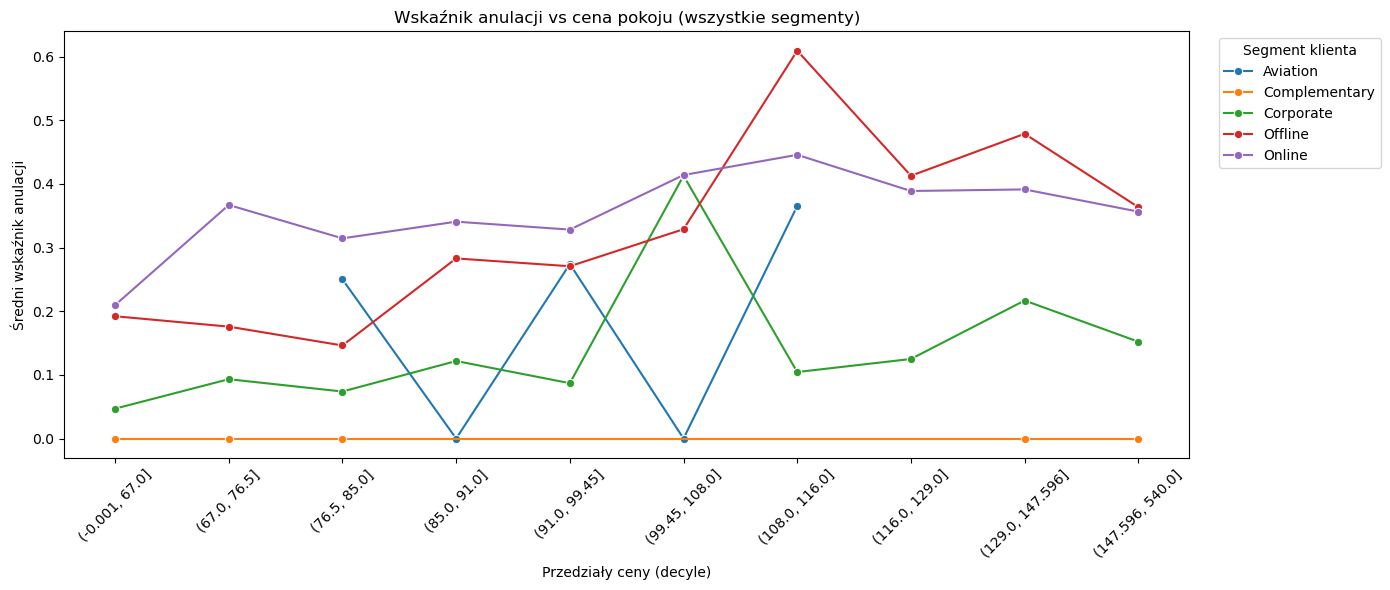

In [ ]:

df_plot = df.copy()

df_plot['price_bin'] = pd.qcut(df_plot['avg_price_per_room'], q=10, duplicates='drop')

segment_price_cancel = (
    df_plot.groupby(['price_bin', 'market_segment_type'])[target_col]
    .mean()
    .reset_index()
)
segment_price_cancel['price_bin'] = segment_price_cancel['price_bin'].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=segment_price_cancel,
    x='price_bin',
    y=target_col,
    hue='market_segment_type',
    marker='o'
)

plt.title('Wskaźnik anulacji vs cena pokoju (wszystkie segmenty)')
plt.xlabel('Przedziały ceny (decyle)')
plt.ylabel('Średni wskaźnik anulacji')
plt.xticks(rotation=45)
plt.legend(title='Segment klienta', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Oprócz tego, że klienci biznesowi są mniej skłonni do anulacji, widać, że wpływ ceny nie jest taki sam w każdym segmencie. 
- w Offline i Online ryzyko anulacji jest bardziej związane z ceną
- w Corporate efekt jest trochę słabszy, jednak nadal związany z ceną
- w małych segmentach (Aviation) dane są niestabilne, a w Complementary dla wszystkich cen pokojów mamy 0 anulacji

Sprawdźmy, czy wpływ lead_time na anulacje różni się między segmentami.


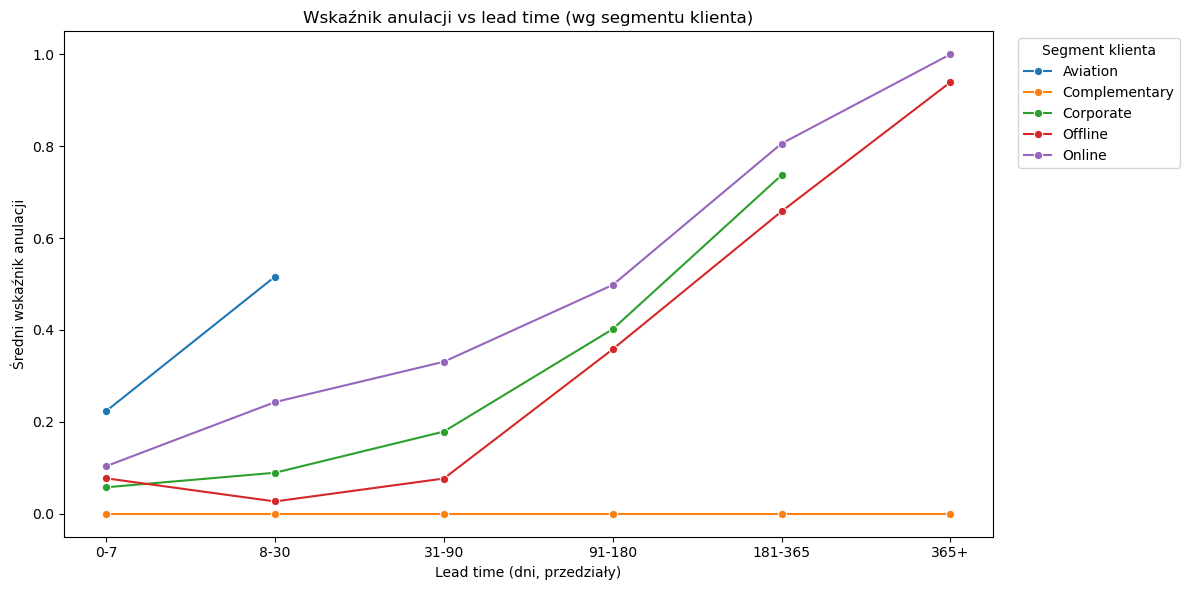

In [36]:

df_plot = df.copy()

df_plot['lead_time_bin'] = pd.cut(
    df_plot['lead_time'],
    bins=[-1, 7, 30, 90, 180, 365, df_plot['lead_time'].max()],
    labels=['0-7', '8-30', '31-90', '91-180', '181-365', '365+']
)
lead_segment_cancel = (
    df_plot.groupby(['lead_time_bin', 'market_segment_type'])[target_col]
    .mean()
    .reset_index()
)
lead_segment_count = (
    df_plot.groupby(['lead_time_bin', 'market_segment_type'])
    .size()
    .reset_index(name='n')
)

lead_segment_summary = lead_segment_cancel.merge(
    lead_segment_count, on=['lead_time_bin', 'market_segment_type']
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=lead_segment_summary,
    x='lead_time_bin',
    y=target_col,
    hue='market_segment_type',
    marker='o'
)

plt.title('Wskaźnik anulacji vs lead time (wg segmentu klienta)')
plt.xlabel('Lead time (dni, przedziały)')
plt.ylabel('Średni wskaźnik anulacji')
plt.legend(title='Segment klienta', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Czy liczba special request obniża anulacje tak samo w każdym segmencie?

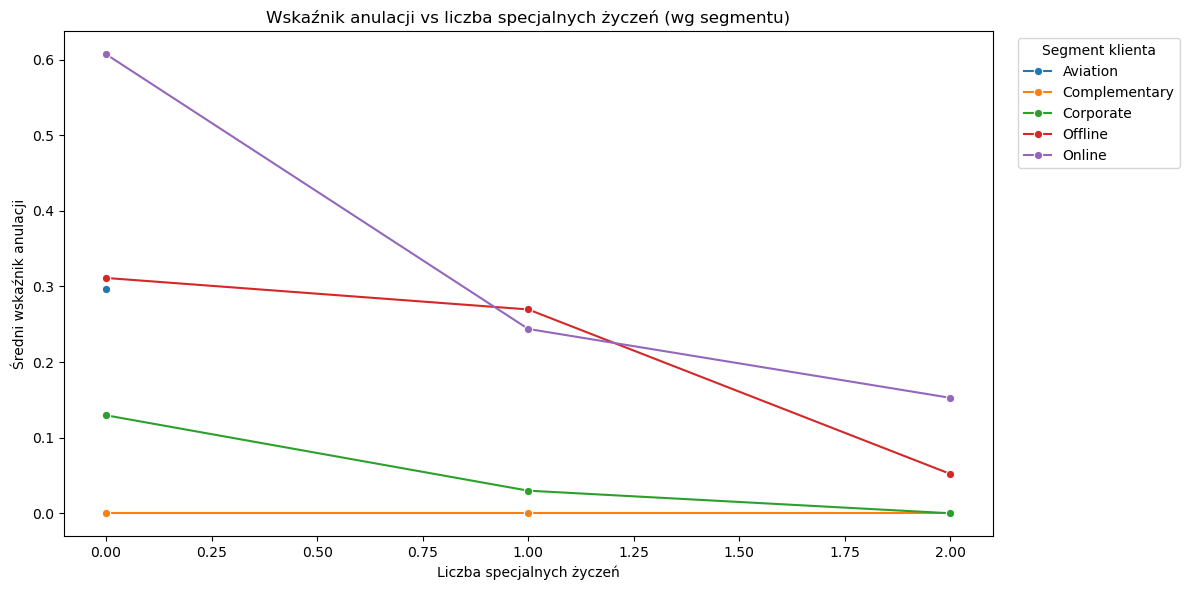

In [ ]:
target = 'booking_status'

df_plot = df.copy()
df_plot = df_plot[df_plot['no_of_special_requests'].isin([0, 1, 2])].copy()

req_segment_cancel = (
    df_plot.groupby(['no_of_special_requests', 'market_segment_type'])[target]
    .mean()
    .reset_index()
)

req_segment_count = (
    df_plot.groupby(['no_of_special_requests', 'market_segment_type'])
    .size()
    .reset_index(name='n')
)

req_segment_summary = req_segment_cancel.merge(
    req_segment_count, on=['no_of_special_requests', 'market_segment_type']
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=req_segment_summary,
    x='no_of_special_requests',
    y=target,
    hue='market_segment_type',
    marker='o'
)

plt.title('Wskaźnik anulacji vs liczba specjalnych życzeń (wg segmentu)')
plt.xlabel('Liczba specjalnych życzeń')
plt.ylabel('Średni wskaźnik anulacji')
plt.legend(title='Segment klienta', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Sezonowość segmentów

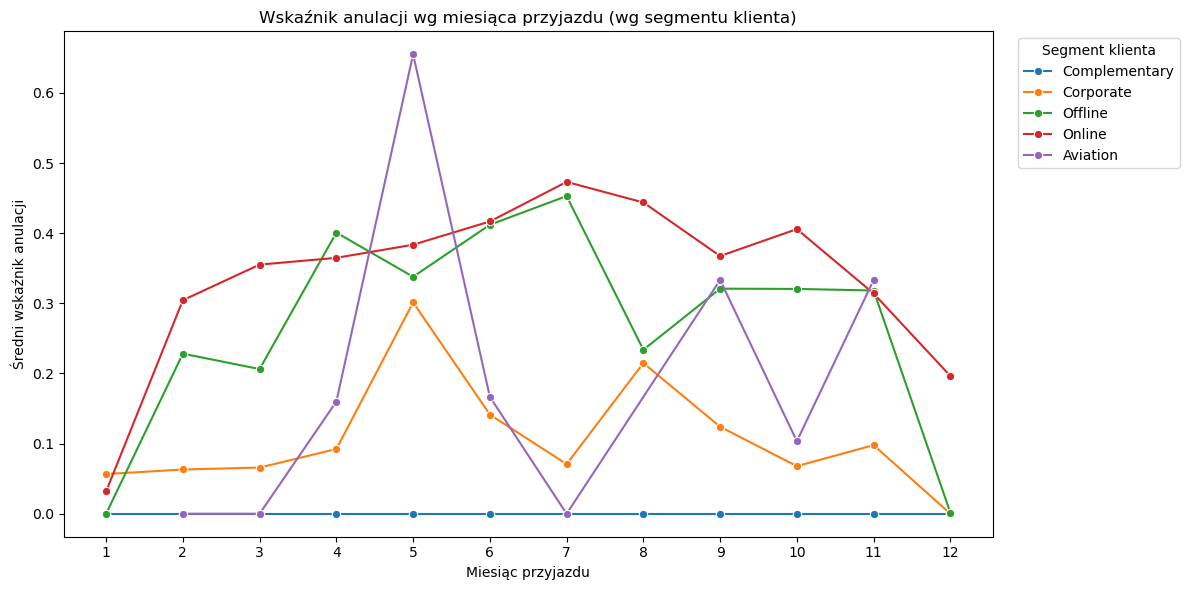

In [ ]:
target = 'booking_status'

df_plot = df.copy()

month_segment_cancel = (
    df_plot.groupby(['arrival_month', 'market_segment_type'])[target]
    .mean()
    .reset_index()
)

month_segment_count = (
    df_plot.groupby(['arrival_month', 'market_segment_type'])
    .size()
    .reset_index(name='n')
)

month_segment_summary = month_segment_cancel.merge(
    month_segment_count, on=['arrival_month', 'market_segment_type']
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=month_segment_summary,
    x='arrival_month',
    y=target,
    hue='market_segment_type',
    marker='o'
)

plt.title('Wskaźnik anulacji wg miesiąca przyjazdu (wg segmentu klienta)')
plt.xlabel('Miesiąc przyjazdu')
plt.ylabel('Średni wskaźnik anulacji')
plt.xticks(range(1, 13))
plt.legend(title='Segment klienta', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **Wnioski biznesowe**

- Warto wdrożyć różne strategie dla rezerwacji z dużym wyprzedzeniem, np. przypomnienia o rezerwacjach, częściowe wpłaty zaliczek.
- Dla droższych rezerwacji warto stosować działania ogtaniczające anulacje, np. benefity 
- Warto aktywnie zachęcać klientów do podawania preferencji po rezerwacji, gdyż może to zmniejszyć ryzyko anulowania rezerwacji
- należy stosować inaczej zarządzać rezewacjami między konkretnymi segmentami, gdyż znacznie różnią się między sobą
- najbardziej ryzykowny profil rezerwacji to offline oraz online
- należy szczególnie zadbać o ograniczenie anulowania rezerwacji w miesiącach letnich/ wiosennych dla segmentu Coroprate